In [241]:
import torch
import PIL.Image
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

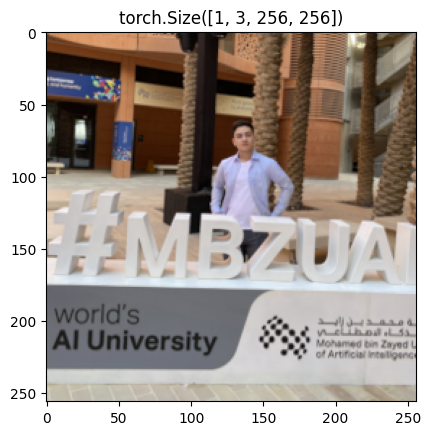

: 

In [ ]:
# Cool picture of me at MBZUAI, my university. C:
sample_image = PIL.Image.open("./sample-nick-mbzuai.png").convert("RGB")
X_sample = torch.tensor(sample_image.getdata()).reshape(1, 256, 256, 3).permute(0, 3, 1, 2) / 255

plt.title(X_sample.shape)
plt.imshow(X_sample[0].permute(1, 2, 0))

In [152]:
class PatchEmbedding(nn.Module):
    def __init__(self, target_resolution=(256, 256), num_patches=(16, 16), embedding_dim=768, in_channels=3):
        super().__init__()

        assert isinstance(target_resolution, (list, tuple)) and len(target_resolution) == 2
        assert isinstance(num_patches, (list, tuple)) and len(num_patches) == 2

        assert target_resolution[0] % num_patches[0] == 0
        assert target_resolution[1] % num_patches[1] == 0

        self.target_resolution = torch.Size(target_resolution)
        self.num_patches = torch.Size(num_patches)
        self.embedding_dim = embedding_dim
        self.in_channels = in_channels

        self.patch_size = (
            self.target_resolution[0] // self.num_patches[0],
            self.target_resolution[1] // self.num_patches[1]
        )

        self.conv_patch = nn.Conv2d(
            in_channels=self.in_channels,
            out_channels=self.embedding_dim,
            kernel_size=self.patch_size,
            stride=self.patch_size
        )
    
    def forward(self, input):
        assert len(input.shape) >= 3
        if len(input.shape) == 3: input = input.unsqueeze(dim=0)
        
        if input.shape[-2:] != self.target_resolution:
            input = F.interpolate(input, size=self.target_resolution, mode="bilinear", antialias=True)
        
        X = self.conv_patch(input)
        X = X.flatten(start_dim=2).transpose(1, 2)

        return X

embedding = PatchEmbedding(target_resolution=(256, 256), num_patches=(16, 16), embedding_dim=768)
embedding(X_sample).shape

torch.Size([1, 256, 768])

![](./figure-vit-architecture.png)

In [246]:
class TransformerEncoderLayer(nn.Module):
    def __init__(self, embedding_dim, num_heads, dropout_p=0.1):
        super().__init__()

        self.embedding_dim = embedding_dim
        self.num_heads = num_heads
        self.dropout_p = dropout_p

        self.head_dim = embedding_dim // num_heads

        self.layer_norm_1 = nn.LayerNorm(normalized_shape=self.embedding_dim)
        self.layer_norm_2 = nn.LayerNorm(normalized_shape=self.embedding_dim)

        self.proj_qkv = nn.Linear(in_features=self.embedding_dim, out_features=3*self.embedding_dim)
        self.proj_out = nn.Linear(in_features=self.embedding_dim, out_features=self.embedding_dim)

        self.dropout = nn.Dropout(p=self.dropout_p)

        self.ffn = nn.Sequential(
            nn.Linear(in_features=self.embedding_dim, out_features=self.embedding_dim*4),
            nn.GELU(),
            nn.Dropout(p=self.dropout_p),
            nn.Linear(in_features=self.embedding_dim*4, out_features=self.embedding_dim),
        )

    def forward(self, X):
        B, T, _ = X.shape

        qkv = self.proj_qkv(X)
        qkv = qkv.reshape(B, T, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)

        Q, K, V = qkv[0], qkv[1], qkv[2]
        
        attn_scores = F.softmax((Q @ K.mT) / (self.head_dim ** 0.5), dim=-1)
        attn_scores = self.dropout(attn_scores)

        X_attn = attn_scores @ V
        X_attn = X_attn.transpose(1, 2).flatten(start_dim=2)
        X_attn = self.proj_out(X_attn)

        X = self.layer_norm_1(X_attn + X)
        X_ffn = self.ffn(X)
        X = self.layer_norm_2(X_ffn + X)

        return X
    
dummy = TransformerEncoderLayer(embedding_dim=768, num_heads=8)
dummy(torch.randn(2, 257, 768)).shape

torch.Size([2, 257, 768])

In [253]:
class TransformerEncoder(nn.Module):
    def __init__(self, embedding_dim, num_layers, num_heads, dropout_p=0.1):
        super().__init__()

        self.embedding_dim = embedding_dim
        self.num_layers = num_layers
        self.num_heads = num_heads
        self.dropout_p = dropout_p

        self.layers = nn.Sequential(*[
            TransformerEncoderLayer(embedding_dim, num_heads, dropout_p)
            for layer in range(self.num_layers)
        ])
    
    def forward(self, X):
        X = self.layers(X)
        return X

dummy = TransformerEncoder(embedding_dim=768, num_layers=4, num_heads=8)
dummy(torch.randn(2, 257, 768)).shape

torch.Size([2, 257, 768])

In [262]:
class LightViTBase(nn.Module):
    def __init__(self, target_resolution=(256, 256), num_patches=(16, 16), embedding_dim=768, num_layers=4, num_heads=8, dropout_p=0.1, in_channels=3):
        super().__init__()

        self.target_resolution = torch.Size(target_resolution)
        self.num_patches = torch.Size(num_patches)
        self.embedding_dim = embedding_dim
        self.num_layers = num_layers
        self.num_heads = num_heads
        self.dropout_p = dropout_p
        self.in_channels = in_channels

        self.embedding = PatchEmbedding(
            target_resolution=self.target_resolution,
            num_patches=self.num_patches,
            embedding_dim=self.embedding_dim,
            in_channels=self.in_channels
        )

        self.positional_embeddings = nn.Parameter(torch.randn(
            size=(1, self.num_patches[0] * self.num_patches[1] + 1, self.embedding_dim)
        ))

        self.cls_token = nn.Parameter(torch.randn(
            size=(1, 1, self.embedding_dim)
        ))

        self.encoder = TransformerEncoder(
            embedding_dim=self.embedding_dim,
            num_layers=self.num_layers,
            num_heads=self.num_heads,
            dropout_p=self.dropout_p
        )

    def forward(self, X):
        X = self.embedding(X)
        X = torch.cat([self.cls_token.repeat(X.shape[0], 1, 1), X], dim=1)
        X = X + self.positional_embeddings
        X = self.encoder(X)
        return X
    
dummy = LightViTBase()
dummy(torch.randn(2, 3, 256, 256)).shape

torch.Size([2, 257, 768])

In [274]:
class LightViTClassifier(nn.Module):
    def __init__(self, target_resolution=(256, 256), num_classes=2, num_patches=(16, 16), embedding_dim=768, num_layers=4, num_heads=8, dropout_p=0.1, in_channels=3):
        super().__init__()

        self.backbone = LightViTBase(
            target_resolution,
            num_patches,
            embedding_dim,
            num_layers,
            num_heads,
            dropout_p,
            in_channels
        )

        self.cls_head = nn.Sequential(
            nn.Linear(in_features=embedding_dim, out_features=embedding_dim*4),
            nn.GELU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(in_features=embedding_dim*4, out_features=num_classes)
        )
    
    def forward(self, X):
        X = self.backbone(X)
        X = self.cls_head(X[:, 0])
        return X

dummy = LightViTClassifier(num_classes=10)
dummy(X_sample)

tensor([[-0.1067,  0.0049,  0.1237, -0.3249,  0.1465,  0.1141, -0.2846,  0.1166,
         -0.1317, -0.1742]], grad_fn=<AddmmBackward0>)